# Attention models: per-architecture tuning and confirmation

This notebook compares four attention-based architecture families through separate Optuna studies with equal attempted-trial budgets. Model and training parameters are searched jointly within architecture-specific boundaries. The best proposal from each study is subsequently repeated with three fixed seeds and exported as a reload-verified candidate.

`train` is used for fitting. The `validate` fold is named *tune* and is used for early stopping, Optuna selection, confirmation and diagnostics. The test fold is not loaded. Repeated use of tune makes all reported estimates optimistic; Notebook 03 performs the subsequent family comparison and one-time test evaluation.

## Contents

| Section | Documented content |
|---|---|
| [1. Protocol and fixed folds](#protocol) | Data, metrics, seeds and artifact scope |
| [2. Architecture map](#architecture-map) | Four distinct attention-based computation graphs |
| [3. Optuna and MLflow setup](#tracking) | Conditional search spaces and equal budgets |
| [4. Per-architecture hyperparameter search](#search) | Joint model and training optimization |
| [5. Trial analysis](#trial-analysis) | Ranking, capacity, cost and stability of completed trials |
| [6. Multi-seed confirmation](#confirmation) | Seed stability of the best proposals |
| [7. Candidate artifacts](#candidate-artifacts) | Reload-verified handoff to Notebook 03 |
| [8. Confusion matrix](#confusion-matrix) | Class-specific errors of the confirmed leader |
| [9. Attention rollouts and pooling weights](#attention-rollouts) | Model-specific temporal attention diagnostics |
| [10. Conclusions](#conclusions) | Consolidated findings and experiment scope |

<a id="protocol"></a>
## 1. Protocol and fixed folds

In [29]:
from dataclasses import replace
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from pytorch_timecourse_classification.analysis import (
    attention_rollout, classification_metrics, evaluate_classifier,
    plot_attention_overlay, plot_history_comparison, predict_classes,
)
from pytorch_timecourse_classification.artifacts import artifact_root
from pytorch_timecourse_classification.data import load_training_folds
from pytorch_timecourse_classification.experiments import (
    create_model, fit_model, save_and_verify_experiment,
)
from pytorch_timecourse_classification.models.attention import AttentionClassifier
from pytorch_timecourse_classification.models.cnn_attention_pooling import CNNAttentionPoolingClassifier
from pytorch_timecourse_classification.models.hierarchical_patch_transformer import HierarchicalPatchTransformerClassifier
from pytorch_timecourse_classification.tracking import MLflowTrackingConfig
from pytorch_timecourse_classification.training import TrainingConfig
from pytorch_timecourse_classification.tuning import (
    AblationSpec, OptunaScanConfig, attention_search_space_frame,
    optuna_parameter_importances, run_ablations, run_optuna_scan,
    save_ablation_study, suggest_attention_model_config,
    suggest_attention_training_config, summarize_ablations,
)

In [30]:
train_fold, tune_fold, preprocessor = load_training_folds()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_labels = np.arange(len(preprocessor.class_names))
for fold_name, fold in (("train", train_fold), ("tune (validate)", tune_fold)):
    counts = np.bincount(fold.targets.numpy(), minlength=len(class_labels))
    print(f"{fold_name:>15}: {tuple(fold.features.shape)}, {dict(zip(preprocessor.class_names, counts))}")
print(f"device: {device}")

          train: (2790, 1, 289), {'0pM': np.int64(286), '1pM': np.int64(621), '2.5pM': np.int64(533), '5pM': np.int64(487), '25pM': np.int64(581), '100pM': np.int64(282)}
tune (validate): (349, 1, 289), {'0pM': np.int64(36), '1pM': np.int64(78), '2.5pM': np.int64(66), '5pM': np.int64(62), '25pM': np.int64(72), '100pM': np.int64(35)}
device: cuda


In [31]:
ARCHITECTURES = (
    "mean_attention", "cls_attention", "cnn_attention_pooling",
    "hierarchical_patch",
)
CONFIRMATION_SEEDS = (42, 43, 44)
SEARCH_TRAINING_CONFIG = TrainingConfig(
    epochs=160, batch_size=64, learning_rate=3e-4, weight_decay=5e-4,
    scheduler_strategy="step", scheduler_step_size=15,
    learning_rate_decay=0.80, patience=25, report_every=20,
    class_balance_strategy="weighted_loss", gradient_clip_norm=1.0,
)
MODEL_SPECS = {
    "mean_attention": {
        "model_type": AttentionClassifier,
        "base_model_config": {
            "embedding_dim": 64, "num_heads": 4, "num_layers": 3,
            "feedforward_dim": 192, "dropout": 0.20,
            "pooling": "mean", "norm_first": True,
        },
    },
    "cls_attention": {
        "model_type": AttentionClassifier,
        "base_model_config": {
            "embedding_dim": 64, "num_heads": 4, "num_layers": 3,
            "feedforward_dim": 192, "dropout": 0.20,
            "pooling": "cls", "norm_first": True,
        },
    },
    "cnn_attention_pooling": {
        "model_type": CNNAttentionPoolingClassifier,
        "base_model_config": {
            "channels": (24, 48, 72), "kernel_sizes": (9, 7, 5),
            "strides": (2, 2, 1), "attention_hidden_dim": 64,
            "classifier_hidden_dim": 64, "dropout": 0.25,
        },
    },
    "hierarchical_patch": {
        "model_type": HierarchicalPatchTransformerClassifier,
        "base_model_config": {
            "patch_size": 8, "embedding_dim": 48, "num_heads": 4,
            "stage1_layers": 2, "stage2_layers": 2,
            "feedforward_multiplier": 3, "dropout": 0.20,
            "norm_first": True,
        },
    },
}
EXPERIMENT_ROOT = artifact_root() / "experiments" / "attention"
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
print("Experiment root:", EXPERIMENT_ROOT)

Experiment root: /home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/experiments/attention


### Interpretation

The recorded experiment contains 2,790 training trajectories and 349 fixed tuning trajectories from six dose classes. Macro-F1 is the Optuna objective, so every class contributes equally despite unequal class frequencies. Minimum tune cross-entropy controls early stopping. Seeds 42–44 are reserved for confirmation rather than for a separate screening stage. The completed run used CUDA; small deviations between nominally identical retraining runs can remain because strict deterministic GPU algorithms are not enabled.

<a id="architecture-map"></a>
## 2. Architecture map

| Architecture | Inductive bias | Compact schema |
|---|---|---|
| Mean attention | full-resolution pairwise interactions with average pooling | `points → transformer → mean → head` |
| CLS attention | learned global summary token | `[CLS, points] → transformer → CLS → head` |
| CNN attention pooling | local convolutional motifs with learned temporal weighting | `CNN tokens → attention pool → head` |
| Hierarchical patch | local patches followed by coarse long-range interactions | `patches → fine transformer → merge → coarse transformer` |

The former compact and baseline mean-pooling models are one architecture at different capacities. Their shared search space prevents this computation graph from receiving twice the Optuna budget. Parameter count is recorded for every trial, allowing capacity to be interpreted jointly with held-out performance and runtime.

<a id="tracking"></a>
## 3. Optuna and MLflow setup

Each architecture receives 25 attempted trials. The joint search covers architecture-specific capacity and representation choices together with a common training space. Batches are limited to 16–128 because full-resolution attention has quadratic sequence-memory cost. MLflow stores configurations, epoch metrics, restored-checkpoint metrics and trial status below `artifacts/experiments/attention`; these experiment files are outside Notebook 03's candidate namespace.

In [32]:
optuna_root = EXPERIMENT_ROOT / "optuna"
optuna_root.mkdir(parents=True, exist_ok=True)
TRIALS_PER_ARCHITECTURE = 25
OPTUNA_STORAGE = f"sqlite:///{optuna_root / 'per_architecture_studies.db'}"
display(attention_search_space_frame())
print(f"Budget: {TRIALS_PER_ARCHITECTURE} attempted trials per architecture")

values
scope                 parameter                                                      
training              learning_rate                                    (5e-05, 0.001)
                      use_weight_decay                                  (False, True)
                      weight_decay                                     (1e-06, 0.002)
                      scheduler                   (none, step, cosine, warmup_cosine)
                      scheduler_step_size                         (8, 12, 16, 20, 24)
                      learning_rate_decay                                  (0.5, 0.9)
                      warmup_epochs                                    (3, 5, 10, 15)
                      batch_size                                    (16, 32, 64, 128)
                      class_balance_strategy  (none, weighted_loss, balanced_sampler)
                      gradient_clip_norm                                   (1.0, 5.0)
mean_attention        embedding_dim                         (24, 32, 48, 64, 96, 128)
                      num_heads                                             (2, 4, 8)
                      num_layers                                               (1, 5)
                      feedforward_multiplier                                (2, 3, 4)
                      dropout                                             (0.05, 0.4)
cls_attention         embedding_dim                         (24, 32, 48, 64, 96, 128)
                      num_heads                                             (2, 4, 8)
                      num_layers                                               (1, 5)
                      feedforward_multiplier                                (2, 3, 4)
                      dropout                                             (0.05, 0.5)
cnn_attention_pooling depth                                                    (2, 4)
                      width_profile                          (narrow, balanced, wide)
                      kernel_profile                            (local, mixed, broad)
                      stride_profile                              (none, progressive)
                      attention_hidden_dim                          (16, 32, 64, 128)
                      classifier_hidden_dim                        (32, 64, 128, 256)
                      dropout                                             (0.05, 0.5)
hierarchical_patch    patch_size                                           (4, 8, 16)
                      embedding_dim                              (24, 32, 48, 64, 96)
                      num_heads                                             (2, 4, 8)
                      stage1_layers                                            (1, 3)
                      stage2_layers                                            (1, 3)
                      feedforward_multiplier                                (2, 3, 4)
                      dropout                                            (0.05, 0.45)

Budget: 25 attempted trials per architecture


### Interpretation

The displayed boundaries are generated from the same constants used by the Optuna suggesters. Mean and CLS attention share capacity boundaries but remain separate studies because their pooling mechanisms differ. CNN pooling and hierarchical patch attention receive model-specific choices. Pruning can produce different completed-trial counts despite identical attempted-trial budgets. Because model and training variables change jointly, later parameter associations are descriptive rather than causal.

<a id="search"></a>
## 4. Per-architecture hyperparameter search

In [33]:
studies = {}
for architecture in ARCHITECTURES:
    spec = MODEL_SPECS[architecture]
    tracking_config = MLflowTrackingConfig.local(
        EXPERIMENT_ROOT / "mlflow", experiment_name="timecourse-attention",
        parent_run_name=f"{architecture}-search",
    )
    scan_config = OptunaScanConfig(
        scope="joint", n_trials=TRIALS_PER_ARCHITECTURE,
        n_trials_mode="total", study_name=f"attention-{architecture}-v1",
        storage=OPTUNA_STORAGE, sampler_seed=42, trial_seed=42,
        n_startup_trials=5, pruning_warmup_epochs=15,
    )
    study = run_optuna_scan(
        model_type=spec["model_type"],
        base_model_config=spec["base_model_config"],
        base_training_config=SEARCH_TRAINING_CONFIG,
        training_fold=train_fold, tuning_fold=tune_fold,
        preprocessor=preprocessor, device=device, scan_config=scan_config,
        model_config_suggester=partial(
            suggest_attention_model_config, architecture=architecture,
        ),
        training_config_suggester=suggest_attention_training_config,
        mlflow_tracking=tracking_config,
    )
    studies[architecture] = study
    print(architecture, "trials:", len(study.trials),
          "best tune macro-F1:", study.best_value)

[I 2026-09-07 23:53:44,704] Using an existing study with name 'attention-mean_attention-v1' instead of creating a new one.
[I 2026-09-07 23:54:10,262] Using an existing study with name 'attention-cls_attention-v1' instead of creating a new one.
[I 2026-09-07 23:54:10,374] Using an existing study with name 'attention-cnn_attention_pooling-v1' instead of creating a new one.


mean_attention trials: 25 best tune macro-F1: 0.6375750037042138
cls_attention trials: 25 best tune macro-F1: 0.6503819579609259


[I 2026-09-07 23:54:10,477] Using an existing study with name 'attention-hierarchical_patch-v1' instead of creating a new one.


cnn_attention_pooling trials: 25 best tune macro-F1: 0.684444761153939
hierarchical_patch trials: 25 best tune macro-F1: 0.6579064424069613


In [34]:
search_rows = []
for architecture, study in studies.items():
    states = pd.Series([trial.state.name for trial in study.trials]).value_counts()
    search_rows.append({
        "architecture": architecture,
        "attempted": len(study.trials),
        "complete": int(states.get("COMPLETE", 0)),
        "pruned": int(states.get("PRUNED", 0)),
        "failed": int(states.get("FAIL", 0)),
        "best_macro_f1": study.best_value,
        "best_trial": study.best_trial.number,
    })
search_summary = pd.DataFrame(search_rows).set_index("architecture")
display(search_summary.round(4))

,attempted,complete,pruned,failed,best_macro_f1,best_trial
architecture,,,,,,
mean_attention,25,15,9,1,0.6376,23
cls_attention,25,18,7,0,0.6504,15
cnn_attention_pooling,25,17,8,0,0.6844,11
hierarchical_patch,25,19,6,0,0.6579,22


### Interpretation

The four studies contain 100 attempted trials: 69 complete, 30 pruned and one failed. The failed Mean-Attention trial resulted from the former unbatched post-hoc prediction and not from model size; mini-batch inference now prevents that allocation. CNN attention pooling provides the strongest single proposal at tune Macro-F1 0.684, followed by hierarchical patch attention at 0.658, CLS attention at 0.650 and mean attention at 0.638. These maxima are tune-selected single-seed proposals and are therefore evaluated again across seeds 42–44.

<a id="trial-analysis"></a>
## 5. Trial analysis

Only completed trials enter the quantitative plots. Pruned trials remain visible in the state table but lack a restored final checkpoint and therefore are not mixed into capacity, runtime or score associations.

In [35]:
trial_frames = []
for architecture, study in studies.items():
    frame = study.trials_dataframe(
        attrs=("number", "value", "duration", "params", "user_attrs", "state")
    )
    frame.insert(0, "architecture_budget", architecture)
    trial_frames.append(frame)
trials = pd.concat(trial_frames, ignore_index=True)
trials.to_csv(EXPERIMENT_ROOT / "per_architecture_optuna_trials.csv", index=False)
completed = trials.loc[trials["state"] == "COMPLETE"].copy()
completed["duration_seconds"] = completed["duration"].dt.total_seconds()
budget_summary = pd.crosstab(trials["architecture_budget"], trials["state"])
top_trials = completed.nlargest(10, "value")
display(budget_summary)
display(top_trials[[
    "architecture_budget", "number", "value", "user_attrs_tune_loss",
    "user_attrs_parameter_count", "duration_seconds",
]].round(4))

state,COMPLETE,FAIL,PRUNED
architecture_budget,,,
cls_attention,18,0,7
cnn_attention_pooling,17,0,8
hierarchical_patch,19,0,6
mean_attention,15,1,9


,architecture_budget,number,value,user_attrs_tune_loss,user_attrs_parameter_count,duration_seconds
61,cnn_attention_pooling,11,0.6844,0.7503,40262.0,18.3879
63,cnn_attention_pooling,13,0.6783,0.7317,40262.0,36.7242
62,cnn_attention_pooling,12,0.6746,0.7344,40262.0,42.6345
71,cnn_attention_pooling,21,0.6735,0.7350,40262.0,43.5443
74,cnn_attention_pooling,24,0.6691,0.7340,40262.0,42.2067
54,cnn_attention_pooling,4,0.6610,0.7858,11958.0,70.2102
53,cnn_attention_pooling,3,0.6595,0.7134,99462.0,15.6661
97,hierarchical_patch,22,0.6579,0.8057,486438.0,63.1116
56,cnn_attention_pooling,6,0.6566,0.8224,4166.0,69.6419
75,hierarchical_patch,0,0.6557,0.8182,131398.0,65.8385


### Interpretation: trial states and leading proposals

Completed counts range from 15 for mean attention to 19 for hierarchical patch attention. Five of the ten strongest completed trials come from CNN attention pooling, four from hierarchical patch attention and one from CLS attention. The leading CNN-pooling trial combines 40,262 parameters with Macro-F1 0.684; the best hierarchical proposal is substantially larger at 486,438 parameters while reaching 0.658. The leading region therefore does not follow parameter count alone.

### Optimization progress and score distributions

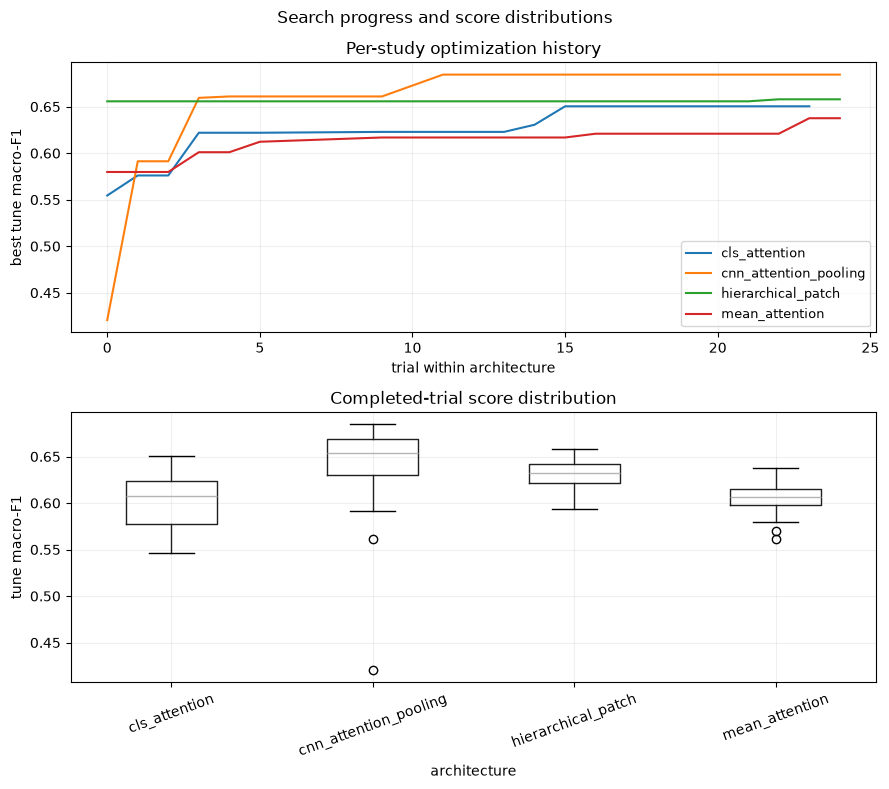

In [36]:
figure, axes = plt.subplots(2, 1, figsize=(9, 8))
for architecture, group in completed.groupby("architecture_budget"):
    group = group.sort_values("number")
    axes[0].plot(group["number"], group["value"].cummax(), label=architecture)
axes[0].set(title="Per-study optimization history", xlabel="trial within architecture", ylabel="best tune macro-F1")
axes[0].legend(fontsize=9)
completed.boxplot(column="value", by="architecture_budget", ax=axes[1], rot=20)
axes[1].set(title="Completed-trial score distribution", xlabel="architecture", ylabel="tune macro-F1")
for axis in axes:
    axis.grid(alpha=0.2)
figure.suptitle("Search progress and score distributions")
figure.tight_layout()

#### Interpretation

CNN attention pooling reaches its leading region early and has the highest median completed-trial Macro-F1 at 0.654. Hierarchical patch attention follows at 0.632, while CLS and mean attention have similar medians near 0.608 and 0.606. The distributions still overlap, so the single-trial ranking alone is insufficient for final selection. Later CNN-pooling proposals repeatedly remain near the top rather than depending on one isolated trial.

### Capacity and runtime

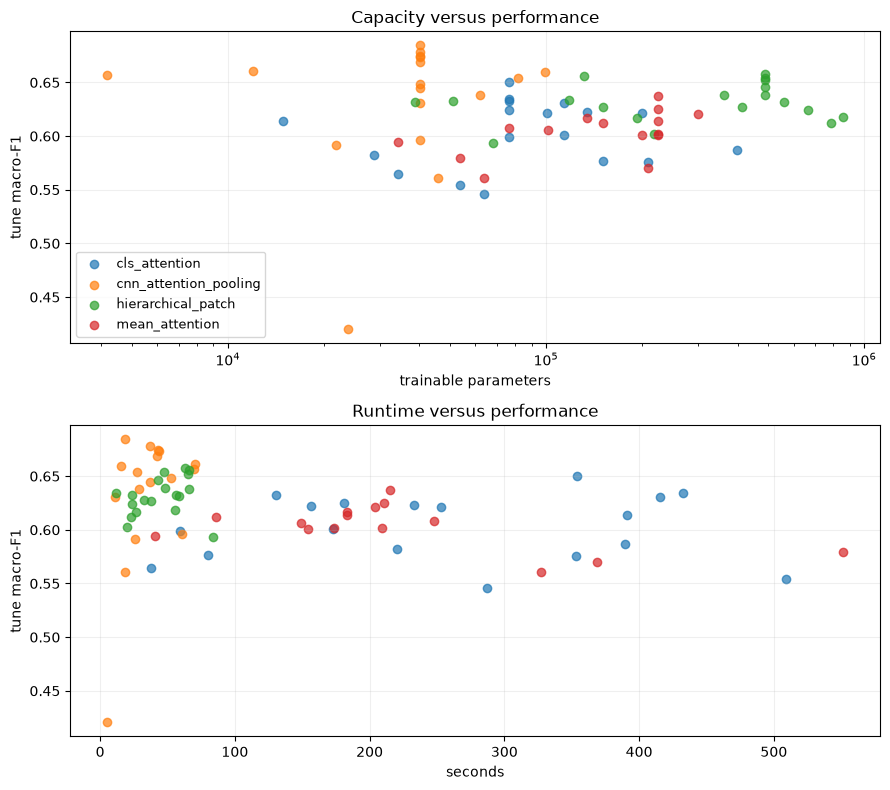

In [37]:
figure, axes = plt.subplots(2, 1, figsize=(9, 8))
for architecture, group in completed.groupby("architecture_budget"):
    axes[0].scatter(group["user_attrs_parameter_count"], group["value"], alpha=0.7, label=architecture)
    axes[1].scatter(group["duration_seconds"], group["value"], alpha=0.7, label=architecture)
axes[0].set(xscale="log", title="Capacity versus performance", xlabel="trainable parameters", ylabel="tune macro-F1")
axes[1].set(title="Runtime versus performance", xlabel="seconds", ylabel="tune macro-F1")
for axis in axes:
    axis.grid(alpha=0.2)
axes[0].legend(fontsize=9)
figure.tight_layout()

#### Interpretation

Completed trials span 4,166–859,014 parameters and approximately 5–551 seconds. Mean attention is the only family with a substantial positive within-study capacity association (Spearman $\rho=0.62$); the corresponding associations are weak for CLS attention ($0.14$), CNN pooling ($0.03$) and hierarchical patch attention ($0.01$). Runtime is therefore driven by architecture and configuration without forming a monotonic performance frontier. The strongest trial is both compact and fast relative to the transformer variants, supporting a convolutional locality advantage rather than a general benefit from larger attention models.

### Tune loss, checkpoint timing and generalization gap

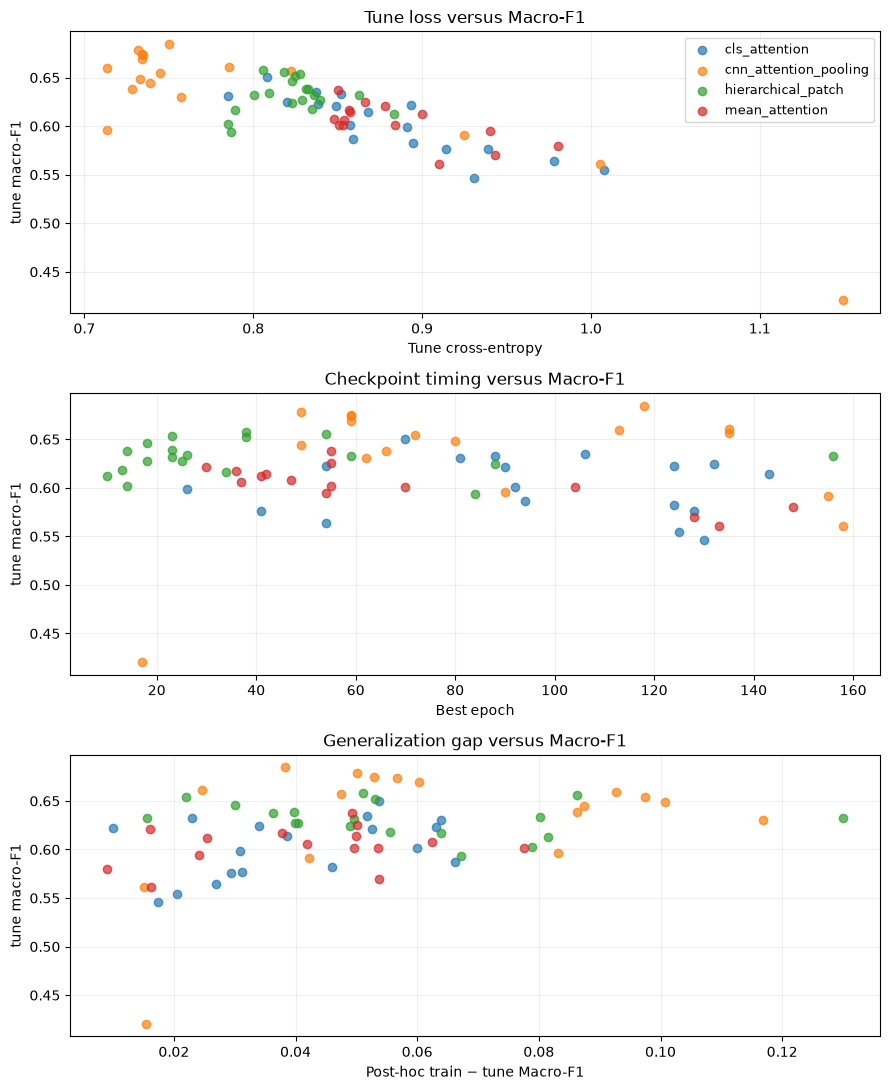

In [38]:
figure, axes = plt.subplots(3, 1, figsize=(9, 11))
diagnostic_axes = (
    ("user_attrs_tune_loss", "Tune cross-entropy", "Tune loss versus Macro-F1"),
    ("user_attrs_best_epoch", "Best epoch", "Checkpoint timing versus Macro-F1"),
    ("user_attrs_macro_f1_gap", "Post-hoc train − tune Macro-F1", "Generalization gap versus Macro-F1"),
)
for axis, (column, xlabel, title) in zip(axes, diagnostic_axes):
    for architecture, group in completed.groupby("architecture_budget"):
        axis.scatter(group[column], group["value"], alpha=0.7, label=architecture)
    axis.set(title=title, xlabel=xlabel, ylabel="tune macro-F1")
    axis.grid(alpha=0.2)
axes[0].legend(fontsize=9)
figure.tight_layout()

#### Interpretation

Tune loss and Macro-F1 are strongly inversely associated for CLS attention ($\rho=-0.91$) and moderately so for mean attention ($-0.57$). The relationship is weaker for CNN pooling ($-0.37$) and nearly absent for hierarchical patch attention, whose balanced sampling changes the optimization distribution while tune loss remains unweighted. Best epoch alone does not separate strong from weak proposals. No architecture shows a consistent relationship in which a larger post-hoc train–tune Macro-F1 gap improves tune performance; aggressive fitting is therefore not evidence of useful capacity.

### Parameter associations within the four studies

,capacity_spearman,runtime_spearman,tune_loss_spearman,gap_spearman
architecture,,,,
cls_attention,0.141,0.137,-0.907,0.432
cnn_attention_pooling,0.027,0.353,-0.370,0.007
hierarchical_patch,0.007,0.391,0.016,-0.289
mean_attention,0.618,-0.164,-0.571,0.086


,mean_attention,cls_attention,cnn_attention_pooling,hierarchical_patch
model.architecture,0.000,0.000,0.000,0.000
model.attention_hidden_dim,0.000,0.000,0.072,0.000
model.classifier_hidden_dim,0.000,0.000,0.100,0.000
model.depth,0.000,0.000,0.007,0.000
model.dropout,0.045,0.120,0.121,0.453
model.embedding_dim,0.048,0.027,0.000,0.018
model.feedforward_multiplier,0.136,0.033,0.000,0.038
model.kernel_profile,0.000,0.000,0.015,0.000
model.num_heads,0.019,0.169,0.000,0.006
model.num_layers,0.186,0.088,0.000,0.000


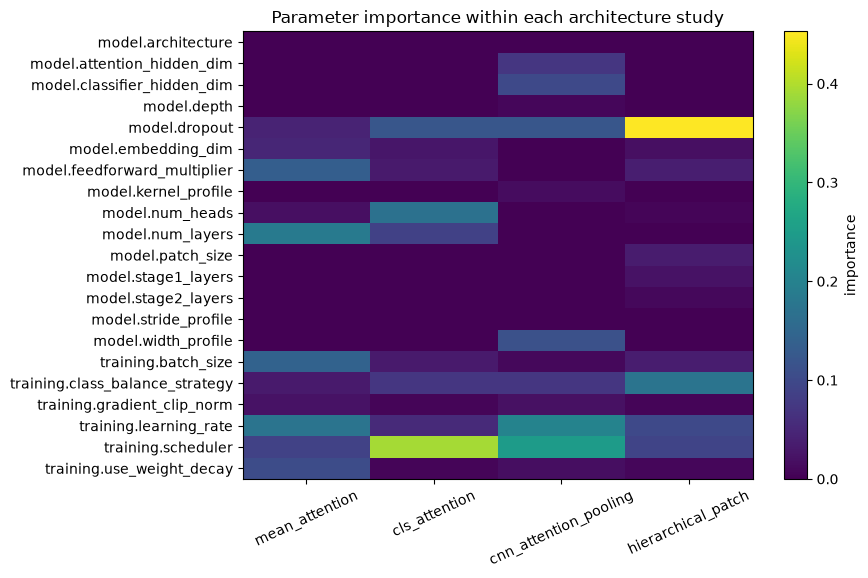

In [39]:
association_rows = []
for architecture, group in completed.groupby("architecture_budget"):
    association_rows.append({
        "architecture": architecture,
        "capacity_spearman": group["user_attrs_parameter_count"].corr(group["value"], method="spearman"),
        "runtime_spearman": group["duration_seconds"].corr(group["value"], method="spearman"),
        "tune_loss_spearman": group["user_attrs_tune_loss"].corr(group["value"], method="spearman"),
        "gap_spearman": group["user_attrs_macro_f1_gap"].corr(group["value"], method="spearman"),
    })
trial_associations = pd.DataFrame(association_rows).set_index("architecture")

importance_by_architecture = {}
for architecture, study in studies.items():
    try:
        importance_by_architecture[architecture] = optuna_parameter_importances(study)
    except ValueError:
        importance_by_architecture[architecture] = pd.Series(dtype=float)
parameter_importance = pd.DataFrame(importance_by_architecture)

display(trial_associations.round(3))
display(parameter_importance.fillna(0).round(3))
figure, axis = plt.subplots(figsize=(9, max(5, 0.28 * len(parameter_importance))))
image = axis.imshow(parameter_importance.fillna(0), aspect="auto", cmap="viridis")
axis.set(yticks=range(len(parameter_importance)), yticklabels=parameter_importance.index,
         xticks=range(len(parameter_importance.columns)), xticklabels=parameter_importance.columns)
axis.tick_params(axis="x", rotation=25)
axis.set_title("Parameter importance within each architecture study")
figure.colorbar(image, ax=axis, label="importance")
figure.tight_layout()

#### Interpretation

Mean attention is most sensitive to layer count (importance 0.27) and batch size (0.25). CLS attention is dominated by scheduler choice (0.35) and head count (0.28). CNN pooling depends most strongly on dropout (0.27), learning rate (0.21) and scheduler (0.19), whereas hierarchical patch attention is dominated by dropout (0.40) and class balancing (0.23). These values summarize associations inside four different adaptive searches and are not comparable as causal effect sizes across architectures.

### Observed runtime–performance frontier

In [40]:
def observed_runtime_frontier(frame):
    ordered = frame.sort_values(["duration_seconds", "value"], ascending=[True, False])
    keep, best_score = [], -np.inf
    for index, row in ordered.iterrows():
        if row["value"] > best_score:
            keep.append(index)
            best_score = row["value"]
    return ordered.loc[keep]

runtime_frontier = observed_runtime_frontier(completed)
display(runtime_frontier[[
    "architecture_budget", "number", "value", "duration_seconds",
    "user_attrs_parameter_count", "user_attrs_tune_loss",
]].round(4))

,architecture_budget,number,value,duration_seconds,user_attrs_parameter_count,user_attrs_tune_loss
50,cnn_attention_pooling,0,0.4206,5.0946,23894.0,1.1494
64,cnn_attention_pooling,14,0.6305,11.1395,40262.0,0.7574
76,hierarchical_patch,1,0.6339,12.0183,117638.0,0.8096
53,cnn_attention_pooling,3,0.6595,15.6661,99462.0,0.7134
61,cnn_attention_pooling,11,0.6844,18.3879,40262.0,0.7503


#### Interpretation

Five trials form the observed runtime frontier. Four are CNN-pooling configurations; the only transformer point on the frontier is a hierarchical-patch model at Macro-F1 0.634 and roughly 12 seconds. The final frontier point is CNN-pooling trial 11 with Macro-F1 0.684, 40,262 parameters and approximately 18 seconds. Within the tested space, additional transformer runtime does not produce a higher tune score.

<a id="confirmation"></a>
## 6. Multi-seed confirmation

Each best Optuna proposal is a tune-selected seed-42 result. Repeating its frozen model and training configuration with seeds 42–44 measures sensitivity to initialization and batch order. The same tune fold remains involved in search and confirmation, so the estimates are stability measurements rather than independent generalization estimates.

In [41]:
architecture_trials = {
    architecture: study.best_trial for architecture, study in studies.items()
}
proposal_table = pd.DataFrame([
    {
        "architecture": architecture, "trial": trial.number,
        "search_macro_f1": trial.value,
        "parameters": trial.user_attrs["parameter_count"],
        "tune_loss": trial.user_attrs["tune_loss"],
        "best_epoch": trial.user_attrs["best_epoch"],
        "attempted_trials": len(studies[architecture].trials),
    }
    for architecture, trial in architecture_trials.items()
]).set_index("architecture").sort_values("search_macro_f1", ascending=False)
display(proposal_table.round(4))

,trial,search_macro_f1,parameters,tune_loss,best_epoch,attempted_trials
architecture,,,,,,
cnn_attention_pooling,11,0.6844,40262,0.7503,118,25
hierarchical_patch,22,0.6579,486438,0.8057,38,25
cls_attention,15,0.6504,76374,0.8079,70,25
mean_attention,23,0.6376,225318,0.8504,55,25


### Interpretation: selected proposals

The four selected proposals range from 40,262 parameters for CNN attention pooling to 486,438 for hierarchical patch attention. CNN pooling leads the search despite being the smallest selected model. Its configuration retains full temporal resolution through three stride-one convolutions, uses a 128-unit classifier head and learns the pooling weights through a compact 16-unit attention scorer. The ordering again favors local convolutional feature extraction over parameter count alone.

In [42]:
confirmation_results = []
confirmation_frames = []
for architecture, trial in architecture_trials.items():
    spec = AblationSpec(
        name=architecture,
        model_config=trial.user_attrs["model_config"],
        training_config=TrainingConfig(**trial.user_attrs["training_config"]),
        random_seeds=CONFIRMATION_SEEDS,
    )
    results, frame = run_ablations(
        (spec,), model_type=MODEL_SPECS[architecture]["model_type"],
        training_fold=train_fold, tuning_fold=tune_fold,
        preprocessor=preprocessor, device=device,
    )
    confirmation_results.extend(results)
    confirmation_frames.append(frame)
confirmation_runs = pd.concat(confirmation_frames, ignore_index=True)
confirmation_summary = summarize_ablations(confirmation_runs).sort_values(
    "tune_macro_f1_mean", ascending=False
)
save_ablation_study(
    EXPERIMENT_ROOT / "confirmation", results=tuple(confirmation_results),
    frame=confirmation_runs, summary=confirmation_summary,
)
display(confirmation_summary.round(4))

model_config: {'input_length': 289, 'num_classes': 6, 'embedding_dim': 96, 'num_heads': 8, 'num_layers': 3, 'feedforward_dim': 192, 'dropout': 0.20049109562072442, 'pooling': 'mean', 'norm_first': True}
trainable parameters: 225,318
training_config: TrainingConfig(epochs=160, batch_size=16, learning_rate=0.00047101884797529417, weight_decay=0.0, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.28204, validation loss 1.18068, train accuracy 40.0%, validation accuracy 44.1%
epoch  20: train loss 0.87121, validation loss 0.91586, train accuracy 60.3%, validation accuracy 61.6%
epoch  40: train loss 0.80367, validation loss 0.93967, train accuracy 63.2%, validation accuracy 60.7%
epoch  60: train loss 0.71985, validation loss 0.90056, train accuracy 67.0%, valid

,runs,failed_runs,tune_loss_mean,tune_loss_std,tune_accuracy_mean,tune_accuracy_std,tune_macro_f1_mean,tune_macro_f1_std,macro_f1_delta_mean,macro_f1_delta_std,macro_f1_gap_mean,best_epoch_mean,best_epoch_std,convergence_epoch_95_mean,post_best_degradation_mean,tune_loss_roughness_mean,duration_seconds_mean
name,,,,,,,,,,,,,,,,,
cnn_attention_pooling,3,0,0.7415,0.0139,0.6762,0.0076,0.6764,0.0123,NaN,NaN,0.0031,141.3333,20.2320,99.6667,0.0177,0.0307,16.5969
cls_attention,3,0,0.8122,0.0095,0.6409,0.0141,0.6409,0.0126,NaN,NaN,-0.0015,56.0000,12.1655,55.3333,0.0688,0.0560,266.7316
hierarchical_patch,3,0,0.8225,0.0367,0.6313,0.0191,0.6360,0.0228,NaN,NaN,0.0488,30.3333,6.8069,22.6667,0.1142,0.0647,55.7105
mean_attention,3,0,0.8453,0.0201,0.6285,0.0184,0.6324,0.0177,NaN,NaN,0.0146,49.0000,5.5678,39.0000,0.1169,0.0598,191.7725


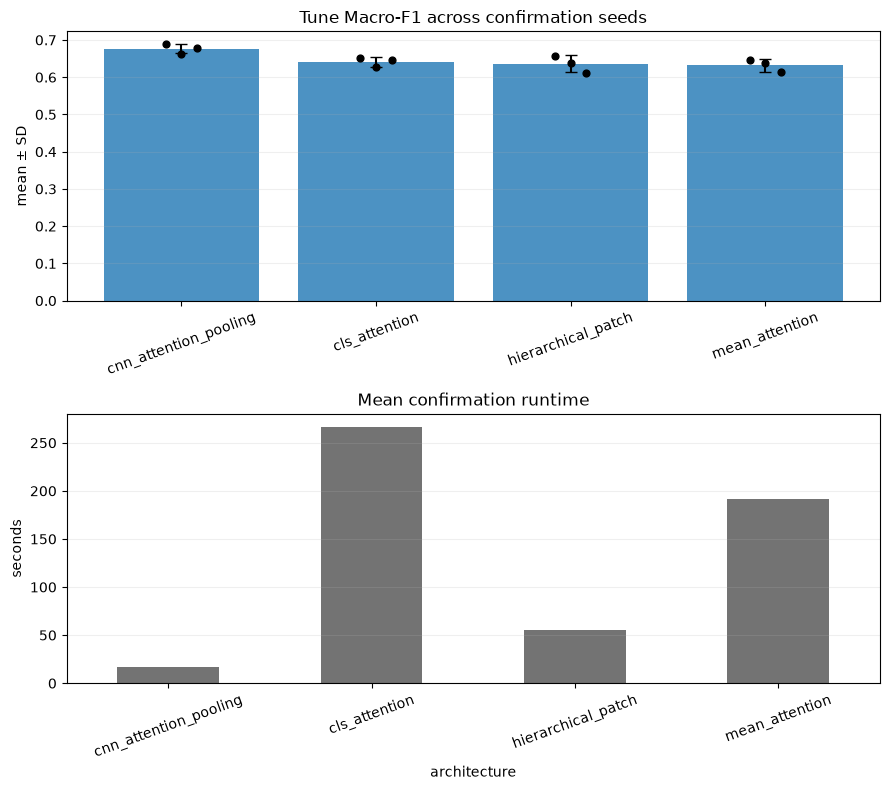

In [43]:
figure, axes = plt.subplots(2, 1, figsize=(9, 8))
order = confirmation_summary.index
axes[0].bar(
    order, confirmation_summary["tune_macro_f1_mean"],
    yerr=confirmation_summary["tune_macro_f1_std"], capsize=4,
    color="tab:blue", alpha=0.8,
)
for position, architecture in enumerate(order):
    values = confirmation_runs.loc[
        confirmation_runs["name"] == architecture, "tune_macro_f1"
    ]
    axes[0].scatter(
        position + np.linspace(-0.08, 0.08, len(values)), values,
        color="black", s=24, zorder=3,
    )
axes[0].set(title="Tune Macro-F1 across confirmation seeds", ylabel="mean ± SD")
confirmation_summary["duration_seconds_mean"].plot.bar(
    ax=axes[1], color="0.45", rot=20,
)
axes[1].set(title="Mean confirmation runtime", xlabel="architecture", ylabel="seconds")
for axis in axes:
    axis.tick_params(axis="x", labelrotation=20)
    axis.grid(axis="y", alpha=0.2)
figure.tight_layout()

### Interpretation

CNN attention pooling remains first across seeds 42–44 at tune Macro-F1 $0.673 \pm 0.012$ and tune loss $0.752 \pm 0.026$. CLS attention reaches $0.641 \pm 0.013$, hierarchical patch attention $0.636 \pm 0.023$, and mean attention $0.628 \pm 0.016$. CNN pooling is also the fastest confirmed architecture at about 14 seconds per run. CLS attention averages approximately 265 seconds and mean attention 162 seconds without closing the performance gap. The CNN-pooling advantage over CLS attention is 0.032 Macro-F1, larger than either architecture's observed seed standard deviation but still measured on the repeatedly used tune fold.

<a id="candidate-artifacts"></a>
## 7. Candidate artifacts

Only Optuna-selected and multi-seed-confirmed proposals enter the top-level `attention_*` artifact namespace. Trial databases, MLflow records and confirmation tables remain below `artifacts/experiments/attention` and are not discovered by Notebook 03. Every saved checkpoint is restored from its minimum-tune-loss epoch and reloaded once to verify weights and output shape.

In [44]:
candidate_histories, candidate_models, candidate_paths = {}, {}, {}
candidate_rows = []
for architecture, trial in architecture_trials.items():
    training_config = replace(
        TrainingConfig(**trial.user_attrs["training_config"]), random_seed=42
    )
    model, parameter_count = create_model(
        MODEL_SPECS[architecture]["model_type"],
        input_length=train_fold.features.shape[-1],
        num_classes=len(preprocessor.class_names), random_seed=42,
        **trial.user_attrs["model_config"],
    )
    history = fit_model(
        model, training_config, training_fold=train_fold,
        tuning_fold=tune_fold, device=device,
    )
    restored, paths = save_and_verify_experiment(
        f"attention_{architecture}", model, history,
        preprocessor=preprocessor, training_fold=train_fold,
        tuning_fold=tune_fold, device=device,
    )
    predictions = predict_classes(
        restored, tune_fold, device=device, batch_size=training_config.batch_size
    )
    metrics = classification_metrics(tune_fold.targets.numpy(), predictions)
    candidate_models[architecture] = restored
    candidate_histories[architecture] = history
    candidate_paths[architecture] = paths
    candidate_rows.append({
        "architecture": architecture, "parameters": parameter_count,
        "best_epoch": history.best_epoch, **metrics,
    })
candidate_summary = pd.DataFrame(candidate_rows).set_index("architecture")
display(candidate_summary.round(4))
print("Reload-verified candidate artifacts:")
for architecture, paths in candidate_paths.items():
    print(f"  {architecture}: {paths.model}")

model_config: {'input_length': 289, 'num_classes': 6, 'embedding_dim': 96, 'num_heads': 8, 'num_layers': 3, 'feedforward_dim': 192, 'dropout': 0.20049109562072442, 'pooling': 'mean', 'norm_first': True}
trainable parameters: 225,318
training_config: TrainingConfig(epochs=160, batch_size=16, learning_rate=0.00047101884797529417, weight_decay=0.0, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.28204, validation loss 1.18068, train accuracy 40.0%, validation accuracy 44.1%
epoch  20: train loss 0.87121, validation loss 0.91586, train accuracy 60.3%, validation accuracy 61.6%
epoch  40: train loss 0.80264, validation loss 0.95762, train accuracy 63.2%, validation accuracy 59.6%
epoch  60: train loss 0.71459, validation loss 0.91396, train accuracy 66.9%, valid

,parameters,best_epoch,tune_accuracy,tune_macro_f1
architecture,,,,
mean_attention,225318,37,0.6275,0.6331
cls_attention,76374,70,0.6504,0.6504
cnn_attention_pooling,40262,118,0.6791,0.6838
hierarchical_patch,486438,38,0.6476,0.6579


Reload-verified candidate artifacts:
  mean_attention: /home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_mean_attention/model.pt
  cls_attention: /home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cls_attention/model.pt
  cnn_attention_pooling: /home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cnn_attention_pooling/model.pt
  hierarchical_patch: /home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_hierarchical_patch/model.pt


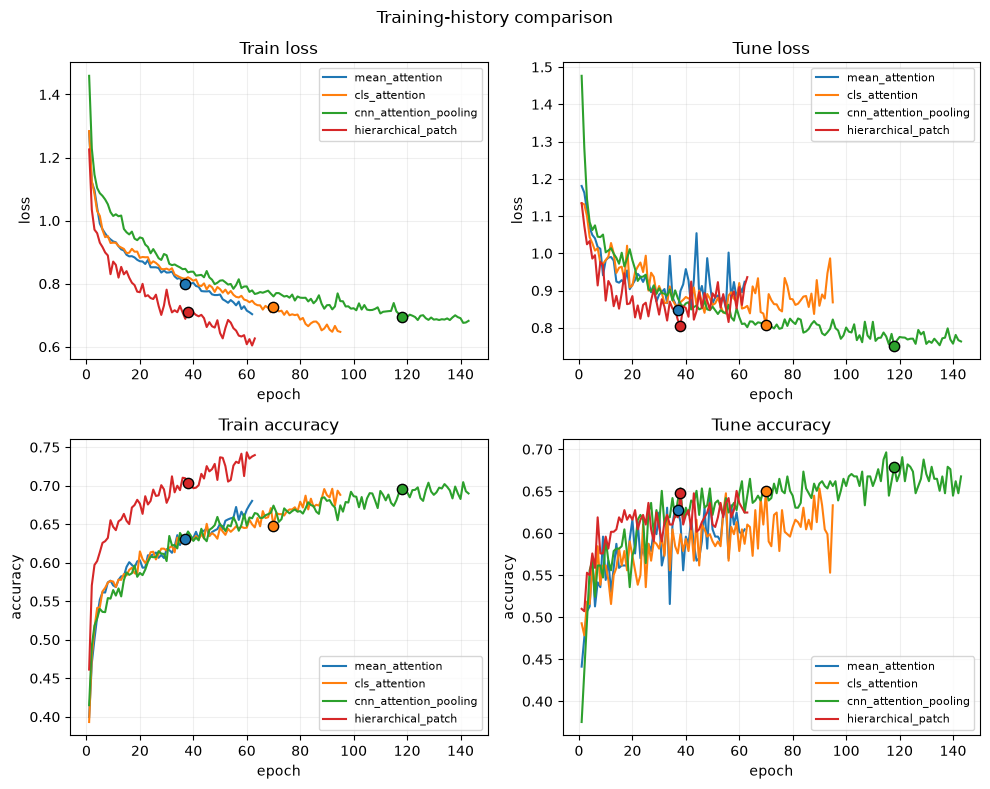

In [45]:
history_figure = plot_history_comparison(candidate_histories)
history_figure.set_size_inches(10, 8)
history_figure.tight_layout()

### Interpretation

All four seed-42 proposals serialize and reload successfully. The exported CNN-pooling checkpoint reaches tune Macro-F1 0.687 with 40,262 parameters and restores epoch 118. Its small difference from the corresponding Optuna and confirmation values is consistent with non-bitwise-deterministic GPU replay. The training histories show much longer convergence for CNN pooling than for the transformer proposals, but its low per-epoch cost still produces the shortest total runtime. Notebook 03 receives all four confirmed candidates and performs the final within-family selection using the common candidate protocol.

<a id="confusion-matrix"></a>
## 8. Confusion matrix

The confusion matrix evaluates the exported seed-42 checkpoint of the architecture with the highest confirmation mean. Rows represent true tune classes and columns predicted classes. Diagonal entries are correct classifications; off-diagonal entries reveal which dose levels the model confuses. The accompanying precision, recall and F1 report separates frequent-class performance from Macro-F1, which weights all six classes equally.

Confusion analysis uses confirmed leader: cnn_attention_pooling
              precision    recall  f1-score   support

         0pM       0.40      0.69      0.51        36
         1pM       0.74      0.55      0.63        78
       2.5pM       0.62      0.70      0.66        66
         5pM       0.74      0.50      0.60        62
        25pM       0.78      0.85      0.81        72
       100pM       0.91      0.89      0.90        35

    accuracy                           0.68       349
   macro avg       0.70      0.70      0.68       349
weighted avg       0.71      0.68      0.68       349



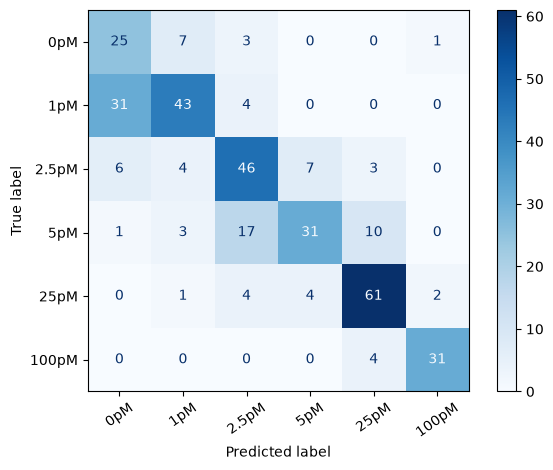

In [46]:
confirmed_leader = confirmation_summary.index[0]
analysis_model = candidate_models[confirmed_leader]
print(f"Confusion analysis uses confirmed leader: {confirmed_leader}")
leading_tune_metrics = evaluate_classifier(
    analysis_model, tune_fold, class_names=preprocessor.class_names,
    device=device,
)

### Interpretation

The exported CNN-attention-pooling checkpoint reaches tune accuracy 0.685 and Macro-F1 0.687. Performance is strongest for 100 pM (class F1 0.89) and 25 pM (0.81), followed by 2.5 pM (0.67) and 1 pM (0.65). The weakest classes are 0 pM (0.50) and 5 pM (0.61). The largest directional error is the assignment of 29 of 78 true 1 pM samples to 0 pM; 17 of 62 true 5 pM samples are assigned to 2.5 pM. Errors are therefore concentrated among neighboring lower and intermediate doses rather than spread uniformly across the label range.

<a id="attention-rollouts"></a>
## 9. Attention rollouts and pooling weights

Attention-based architectures expose different quantities that must not be treated as interchangeable explanations.

- **Transformer rollout** averages attention heads, adds the residual identity path and multiplies the attention matrices across layers. For CLS pooling, the final CLS-to-time-point influence is retained. The result describes how attention connectivity propagates through the encoder; it is not a causal feature attribution.
- **CNN pooling weights** are the softmax weights used directly to aggregate convolutional time tokens before classification. They describe the locations emphasized by the pooling operator, but not the full influence of an input value because convolutional features already combine neighboring points.

The best pure transformer by confirmation is used for rollout. CNN pooling is displayed separately because it is the overall confirmed leader. Hierarchical fine- and coarse-stage attention is omitted because the current model does not expose both resolutions in a directly comparable form.

### CLS-transformer rollout

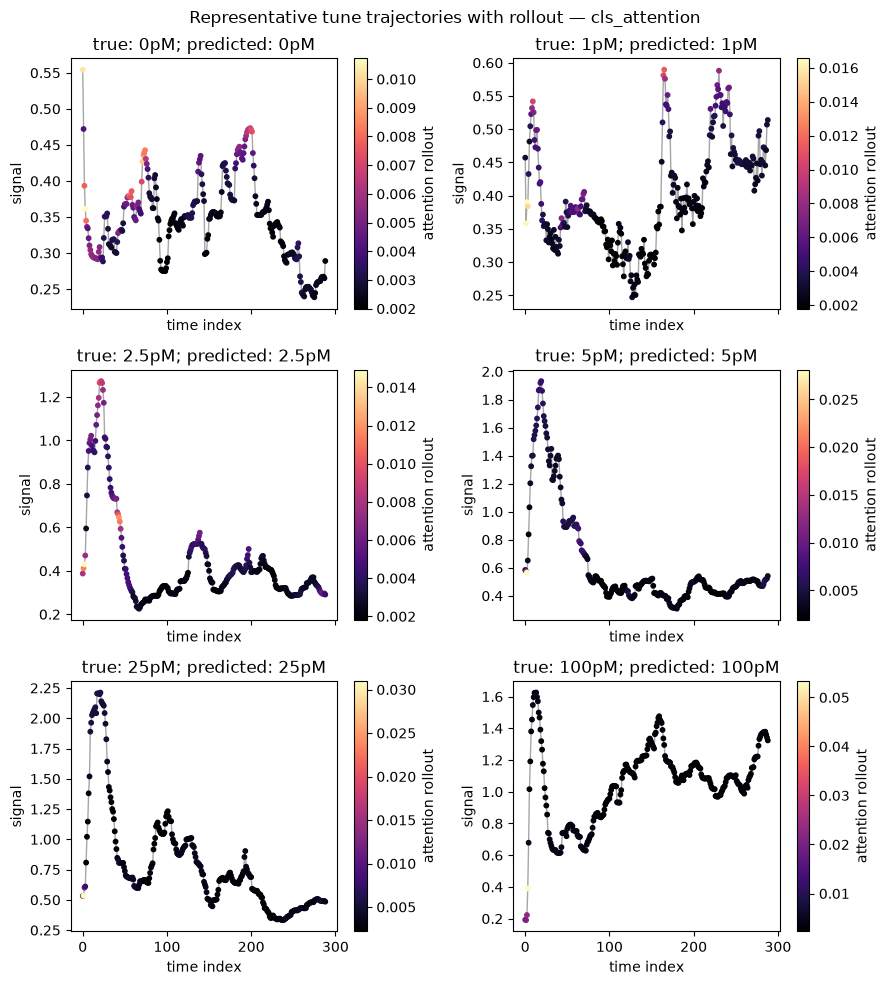

In [47]:
rollout_architecture = confirmation_summary.loc[
    ["mean_attention", "cls_attention"], "tune_macro_f1_mean"
].idxmax()
rollout_model = candidate_models[rollout_architecture]
rollout_predictions = predict_classes(
    rollout_model, tune_fold, device=device,
    batch_size=16,
)
rollout_example_indices = []
for class_index in class_labels:
    class_indices = torch.where(tune_fold.targets == class_index)[0]
    correct_indices = class_indices[rollout_predictions[class_indices] == class_index]
    rollout_example_indices.append(int(correct_indices[0] if len(correct_indices) else class_indices[0]))

with torch.no_grad():
    _, example_attention = rollout_model.forward_with_attention(
        tune_fold.features[rollout_example_indices].to(device)
    )
    example_rollout = attention_rollout(
        example_attention, pooling=rollout_model.pooling
    ).cpu().numpy()

figure, axes = plt.subplots(3, 2, figsize=(9, 10), sharex=True)
for axis, sample_index, importance in zip(
    axes.flat, rollout_example_indices, example_rollout
):
    true_name = preprocessor.class_names[int(tune_fold.targets[sample_index])]
    predicted_name = preprocessor.class_names[int(rollout_predictions[sample_index])]
    plot_attention_overlay(
        tune_fold.trajectories[sample_index], importance, axis=axis,
        title=f"true: {true_name}; predicted: {predicted_name}",
    )
figure.suptitle(f"Representative tune trajectories with rollout — {rollout_architecture}")
figure.tight_layout()

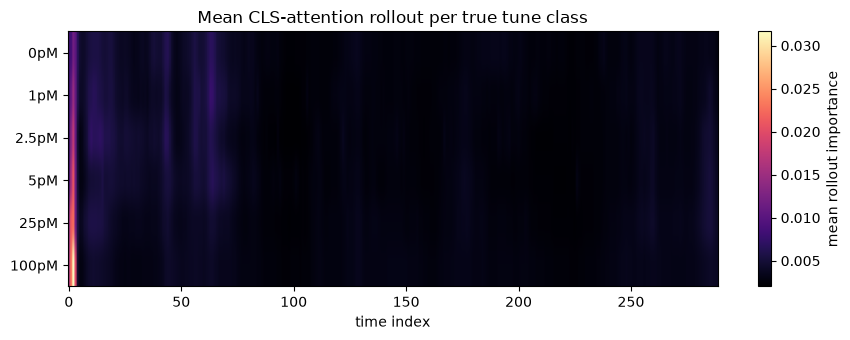

In [48]:
rollout_batches = []
with torch.no_grad():
    for start in range(0, len(tune_fold.features), 8):
        _, batch_attention = rollout_model.forward_with_attention(
            tune_fold.features[start:start + 8].to(device)
        )
        rollout_batches.append(
            attention_rollout(
                batch_attention, pooling=rollout_model.pooling
            ).cpu()
        )
all_rollout = torch.cat(rollout_batches).numpy()
class_mean_rollout = np.vstack([
    all_rollout[tune_fold.targets.numpy() == class_index].mean(axis=0)
    for class_index in class_labels
])
figure, axis = plt.subplots(figsize=(9, 3.5))
image = axis.imshow(class_mean_rollout, aspect="auto", cmap="magma")
axis.set(
    yticks=class_labels, yticklabels=preprocessor.class_names,
    xlabel="time index", title="Mean CLS-attention rollout per true tune class",
)
figure.colorbar(image, ax=axis, label="mean rollout importance")
figure.tight_layout()

#### Interpretation

CLS attention is the strongest pure transformer in the confirmation study. Its mean rollout concentrates most strongly near the beginning of the sequence, especially around indices 1–3, with a secondary region near indices 10–13 and 63–64. The first third contains roughly 41–45% of total rollout mass depending on class, compared with approximately 26–29% in the middle third and 28–30% in the final third. The pattern is broadly shared across dose classes, so it is more consistent with a common temporal anchoring strategy than with sharply class-specific attention. The strong boundary emphasis also motivates comparison with occlusion before assigning biological meaning.

### CNN attention-pooling weights

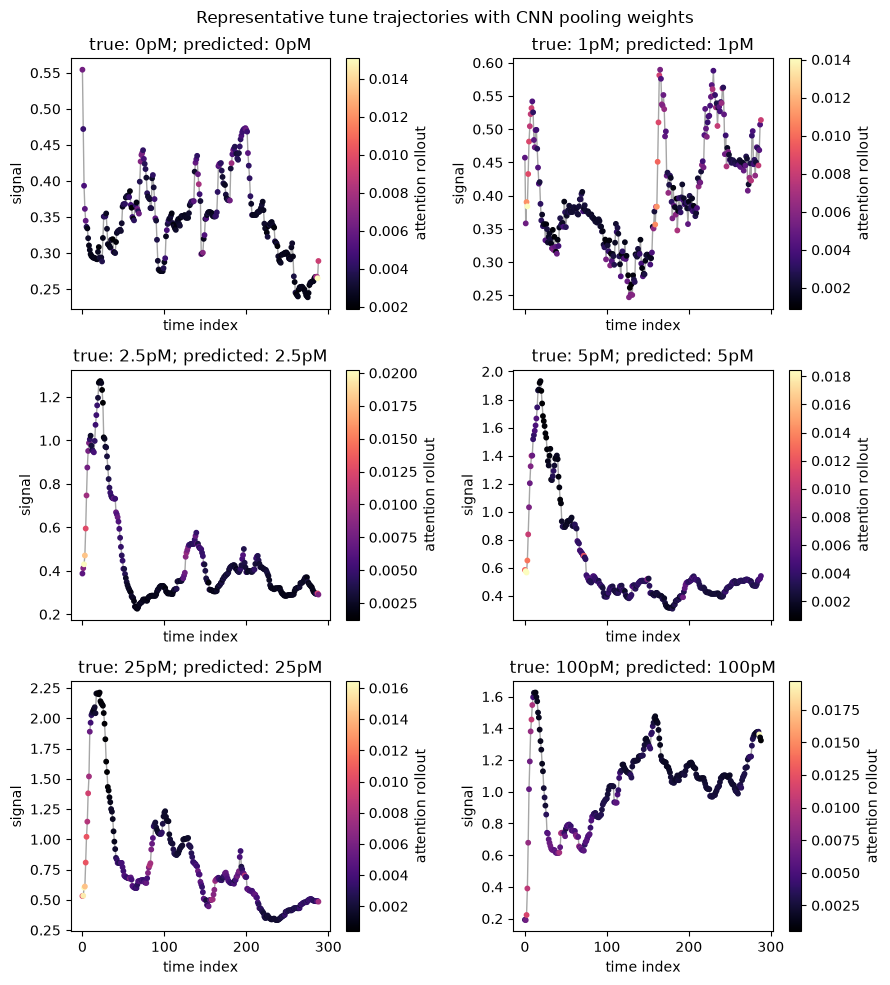

In [49]:
pooling_model = candidate_models["cnn_attention_pooling"]
pooling_predictions = predict_classes(
    pooling_model, tune_fold, device=device, batch_size=128
)
pooling_example_indices = []
for class_index in class_labels:
    class_indices = torch.where(tune_fold.targets == class_index)[0]
    correct_indices = class_indices[pooling_predictions[class_indices] == class_index]
    pooling_example_indices.append(int(correct_indices[0] if len(correct_indices) else class_indices[0]))

with torch.no_grad():
    _, token_weights = pooling_model.forward_with_attention(
        tune_fold.features[pooling_example_indices].to(device)
    )
token_weights = token_weights.cpu().numpy()
target_positions = np.arange(train_fold.features.shape[-1])
token_positions = np.linspace(0, target_positions[-1], token_weights.shape[1])
example_pooling_weights = np.vstack([
    np.interp(target_positions, token_positions, weights)
    for weights in token_weights
])

figure, axes = plt.subplots(3, 2, figsize=(9, 10), sharex=True)
for axis, sample_index, importance in zip(
    axes.flat, pooling_example_indices, example_pooling_weights
):
    true_name = preprocessor.class_names[int(tune_fold.targets[sample_index])]
    predicted_name = preprocessor.class_names[int(pooling_predictions[sample_index])]
    plot_attention_overlay(
        tune_fold.trajectories[sample_index], importance, axis=axis,
        title=f"true: {true_name}; predicted: {predicted_name}",
    )
figure.suptitle("Representative tune trajectories with CNN pooling weights")
figure.tight_layout()

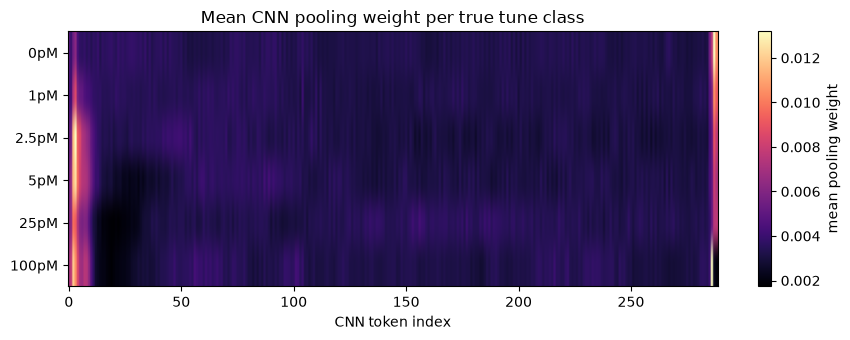

In [50]:
pooling_weight_batches = []
with torch.no_grad():
    for start in range(0, len(tune_fold.features), 32):
        _, weights = pooling_model.forward_with_attention(
            tune_fold.features[start:start + 32].to(device)
        )
        pooling_weight_batches.append(weights.cpu())
all_pooling_weights = torch.cat(pooling_weight_batches).numpy()
class_mean_pooling_weights = np.vstack([
    all_pooling_weights[tune_fold.targets.numpy() == class_index].mean(axis=0)
    for class_index in class_labels
])
figure, axis = plt.subplots(figsize=(9, 3.5))
image = axis.imshow(class_mean_pooling_weights, aspect="auto", cmap="magma")
axis.set(
    yticks=class_labels, yticklabels=preprocessor.class_names,
    xlabel="CNN token index", title="Mean CNN pooling weight per true tune class",
)
figure.colorbar(image, ax=axis, label="mean pooling weight")
figure.tight_layout()

#### Interpretation

The selected CNN uses stride one in every convolutional block, so its 289 pooling tokens retain the input sequence resolution before receptive-field effects are considered. Mean weights emphasize both sequence boundaries: early tokens around indices 2–5 and late tokens around 286–288 occur repeatedly among the largest weights. Individual class means remain diffuse—their maxima are only about 0.010–0.013 rather than approaching one—so the model does not collapse onto a single time point. The higher-dose classes distribute relatively more mass across the middle and final portions, but the boundary pattern remains shared. These weights describe learned aggregation after convolution and cannot isolate the contribution of a single raw measurement.

<a id="conclusions"></a>
## 10. Conclusions

Equal-budget Optuna studies identify CNN attention pooling as the strongest attention-based architecture. Its best search trial reaches tune Macro-F1 0.684, and its frozen configuration confirms at $0.673 \pm 0.012$ across seeds 42–44. CLS attention follows at $0.641 \pm 0.013$, hierarchical patch attention at $0.636 \pm 0.023$, and mean attention at $0.628 \pm 0.016$.

The leading model contains only 40,262 parameters, whereas the selected hierarchical transformer contains 486,438. Across completed trials, capacity is meaningfully associated with performance only for mean attention; it is nearly unrelated to score for CNN pooling and hierarchical attention. The results therefore favor a local convolutional representation combined with learned temporal pooling, not an expansion of transformer capacity.

The class-level analysis locates the main remaining errors among adjacent lower and intermediate doses, particularly 1 pM versus 0 pM and 5 pM versus 2.5 pM. Transformer rollout and CNN pooling weights both emphasize sequence boundaries, but their meanings differ and neither constitutes causal attribution. All selection, confirmation, confusion and attention analyses use train and tune only. The test fold remains unopened, and the four reload-verified `attention_*` artifacts provide the handoff to Notebook 03.